In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Load COT
cot = pd.read_csv('cot_clean.csv', parse_dates=['date', 'tradeable_date'])

# Load EOD price data
tickers = {'corn': 'ZS=F', 'soy': 'ZC=F', 'hogs': 'HE=F','live_cattle': 'LE=F','feeder_cattle': 'GF=F'}
eod = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start='2000-01-01', auto_adjust=True)
    df.columns = ['_'.join(col).strip('_') for col in df.columns]
    eod[name] = df
    print(f"{name}: {len(df)} rows")

[*********************100%***********************]  1 of 1 completed


corn: 6453 rows


[*********************100%***********************]  1 of 1 completed


soy: 6461 rows


[*********************100%***********************]  1 of 1 completed


hogs: 6384 rows


[*********************100%***********************]  1 of 1 completed


live_cattle: 6316 rows


[*********************100%***********************]  1 of 1 completed

feeder_cattle: 6286 rows


In [4]:
cot_market_map = {
    'CORN - CHICAGO BOARD OF TRADE': ('corn', 'ZS=F'),
    'SOYBEANS - CHICAGO BOARD OF TRADE': ('soy', 'ZC=F'),
    'LEAN HOGS - CHICAGO MERCANTILE EXCHANGE': ('hogs', 'HE=F'),
    'LIVE CATTLE - CHICAGO MERCANTILE EXCHANGE': ('live_cattle', 'LE=F'),
    'FEEDER CATTLE - CHICAGO MERCANTILE EXCHANGE': ('feeder_cattle', 'GF=F')
}

In [33]:
# =========================================================
# Commercial Position Structure Summary
# =========================================================

structure_rows = []

for cot_name, (short_name, ticker) in cot_market_map.items():
    df = cot[cot["Market and Exchange Names"] == cot_name].copy()

    avg_comm_long = df["Commercial Positions-Long (All)"].mean()
    avg_comm_short = df["Commercial Positions-Short (All)"].mean()
    avg_comm_net = df["comm_net"].mean()
    avg_open_interest = df["Open Interest (All)"].mean()

    avg_comm_share_oi = (
        (df["Commercial Positions-Long (All)"] +
         df["Commercial Positions-Short (All)"]).mean()
        / avg_open_interest
    )

    pct_weeks_net_short = (df["comm_net"] < 0).mean()

    structure_rows.append({
        "Market": short_name,
        "Avg Comm Net": avg_comm_net,
        "Avg Open Interest": avg_open_interest,
        "Commercial Participation Ratio": avg_comm_share_oi,
        "% Weeks Net Short": pct_weeks_net_short
    })

commercial_structure_df = pd.DataFrame(structure_rows)

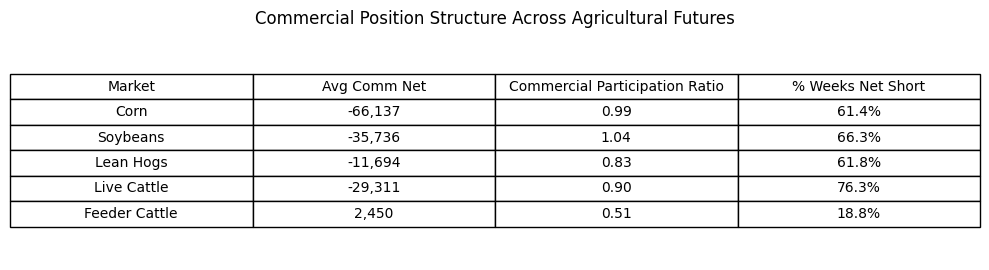

In [39]:
# ---------------------------------
# Select and format display columns
# ---------------------------------

table_df = commercial_structure_df.copy()

display_names = {
    "corn": "Corn",
    "soy": "Soybeans",
    "hogs": "Lean Hogs",
    "live_cattle": "Live Cattle",
    "feeder_cattle": "Feeder Cattle"
}

table_df["Market"] = table_df["Market"].map(display_names)

table_df["Avg Comm Net"] = (
    table_df["Avg Comm Net"]
    .map(lambda x: f"{x:,.0f}")
)

table_df["Commercial Participation Ratio"] = (
    table_df["Commercial Participation Ratio"]
    .map(lambda x: f"{x:.2f}")
)

table_df["% Weeks Net Short"] = (
    table_df["% Weeks Net Short"]
    .map(lambda x: f"{x:.1%}")
)

table_df = table_df[
    [
        "Market",
        "Avg Comm Net",
        "Commercial Participation Ratio",
        "% Weeks Net Short"
    ]
]

# ---------------------------------
# Create matplotlib table
# ---------------------------------

fig, ax = plt.subplots(figsize=(10, 2.8))

ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title(
    "Commercial Position Structure Across Agricultural Futures",
    fontsize=12,
    pad=12
)

plt.tight_layout()
plt.show()

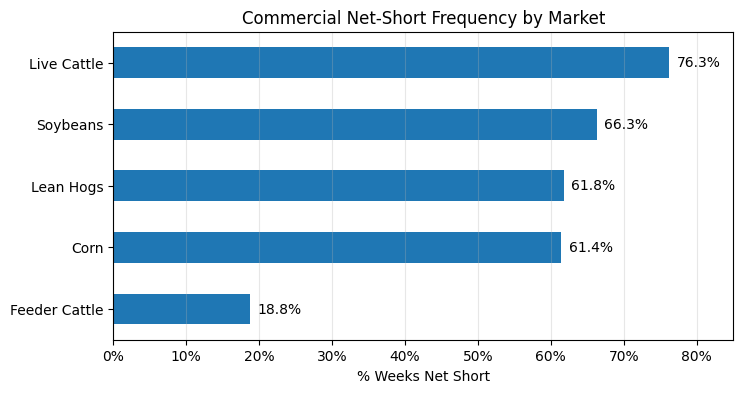

In [46]:
import matplotlib.ticker as mtick

plot_df = commercial_structure_df.copy()

plot_df["Market"] = plot_df["Market"].map(display_names)

plot_df = plot_df.sort_values("% Weeks Net Short", ascending=True)

plot_df.plot(
    x="Market",
    y="% Weeks Net Short",
    kind="barh",
    figsize=(8,4),
    legend=False,
    title="Commercial Net-Short Frequency by Market"
)

plt.xlabel("% Weeks Net Short")
plt.ylabel("")
plt.xlim(0, 0.85)

plt.grid(axis="x", alpha=0.3)

for i, v in enumerate(plot_df["% Weeks Net Short"]):
    plt.text(v + 0.01, i, f"{v:.1%}", va='center')

ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

In [7]:
#Remove, maybe move and change

rows = []

for name, df in eod.items():

    close = df.filter(like="Close").iloc[:,0]
    high  = df.filter(like="High").iloc[:,0]
    low   = df.filter(like="Low").iloc[:,0]

    returns = close.pct_change().dropna()
    ranges = (high - low) / close

    rows.append({
        "market": name,
        "volatility": returns.std(),
        "avg_abs_return": returns.abs().mean(),
        "avg_range": ranges.mean()
    })

table = pd.DataFrame(rows)
print(table.round(4))

          market  volatility  avg_abs_return  avg_range
0           corn      0.0157          0.0110     0.0162
1            soy      0.0177          0.0126     0.0197
2           hogs      0.0233          0.0131     0.0161
3    live_cattle      0.0113          0.0076     0.0103
4  feeder_cattle      0.0105          0.0069     0.0095


In [15]:
def backtest_cot_sized(df, long_thresh=0.8, short_thresh=0.2, long_only=False,
                       target_vol=0.01, vol_window=20, silent=False):

    df = df.copy()

    if "ret" not in df.columns:
        close_col = next(c for c in df.columns if "Close" in c)
        df["ret"] = df[close_col].pct_change()

    df = df.dropna(subset=['cot_idx','ret'])

    df['signal'] = 0
    df.loc[df['cot_idx'] > long_thresh, 'signal'] = 1
    if not long_only:
        df.loc[df['cot_idx'] < short_thresh, 'signal'] = -1

    df['signal'] = df['signal'].shift(1)

    # realized volatility
    df['vol'] = df['ret'].rolling(vol_window).std()

    # avoid divide-by-zero
    df['vol'] = df['vol'].replace(0, np.nan)

    df['size'] = (target_vol / df['vol']).clip(0.1, 3.0)
    df['size'] = df['size'].shift(1)

    df = df.dropna(subset=['size'])

    df['strat_ret'] = df['signal'] * df['size'] * df['ret']
    df['equity'] = (1 + df['strat_ret']).cumprod()

    total_ret = df['equity'].iloc[-1] - 1
    annual_ret = (1 + total_ret) ** (252 / len(df)) - 1

    std = df['strat_ret'].std()
    sharpe = 0 if std == 0 else df['strat_ret'].mean() / std * (252 ** 0.5)

    max_dd = (df['equity'] / df['equity'].cummax() - 1).min()

    trades = df[df['signal'] != 0]['strat_ret']
    win_rate = (trades > 0).mean() if len(trades) else 0
    n_trades = len(trades)

    metrics = dict(
        annual=annual_ret,
        sharpe=sharpe,
        max_dd=max_dd,
        win_rate=win_rate,
        n_days=n_trades
    )

    if not silent:
        for k, v in metrics.items():
            print(f"{k}: {v:.3f}")

    return df, metrics

In [16]:

periods = {
    "2008-2012": ("2008-01-01", "2012-12-31"),
    "2013-2016": ("2013-01-01", "2016-12-31"),
    "2017-2020": ("2017-01-01", "2020-12-31"),
    "2021-2024": ("2021-01-01", "2024-12-31"),
}

market_labels = {
    "corn": "Corn",
    "soy": "Soybeans",
    "hogs": "Lean Hogs",
    "live_cattle": "Live Cattle",
    "feeder_cattle": "Feeder Cattle",
}

for market, label in market_labels.items():
    print(f"\n{label}:")
    print(f"{'Period':<12} {'Annual':>8} {'Sharpe':>8} {'MaxDD':>8} {'WinRate':>8}")

    for period_name, (start, end) in periods.items():
        period_df = merged[market].loc[start:end].copy()
        _, m = backtest_cot_sized(period_df, long_only=True, silent=True)
        print(
            f"{period_name:<12} {m['annual']:>8.2%} {m['sharpe']:>8.3f} "
            f"{m['max_dd']:>8.2%} {m['win_rate']:>8.2%}"
        )


Corn:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012       5.97%    0.618  -11.74%   55.06%
2013-2016       3.48%    0.376  -16.74%   52.71%
2017-2020       2.62%    0.329  -19.08%   48.41%
2021-2024      -7.10%   -0.651  -26.11%   49.39%

Soybeans:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012      -1.44%   -0.136  -18.58%   49.22%
2013-2016      -4.92%   -0.353  -32.89%   50.00%
2017-2020       5.45%    0.640   -9.74%   55.65%
2021-2024       0.94%    0.142  -22.59%   46.94%

Lean Hogs:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012      11.04%    0.657   -8.18%   47.27%
2013-2016       1.87%    0.225  -20.53%   54.58%
2017-2020       0.41%    0.096  -21.71%   47.24%
2021-2024       5.00%    0.387  -21.92%   46.21%

Live Cattle:
Period         Annual   Sharpe    MaxDD  WinRate
2008-2012      -0.22%    0.022  -22.92%   49.71%
2013-2016      -2.22%   -0.214  -21.56%   48.65%
2017-2020      -2.30%   -0.113  -24.66%   50.76%
2021-2024       2.17%    

In [17]:
for market, label in market_labels.items():
    print(f"\n{'='*40}\n{label}")
    
    for name, (start, end) in periods.items():
        d = merged[market].loc[start:end]
        
        long_ext = d['cot_idx'] > 0.8
        short_ext = d['cot_idx'] < 0.2
        flat = ~long_ext & ~short_ext
        
        print(f"\n{name}")
        print(d['cot_idx'].describe()[['mean', 'std', 'min', 'max']])
        print(f"Extreme long:  {long_ext.sum():4d}  ({long_ext.mean():.3f})")
        print(f"Extreme short: {short_ext.sum():4d}  ({short_ext.mean():.3f})")
        print(f"Flat:          {flat.sum():4d}  ({flat.mean():.3f})")



Corn

2008-2012
mean    0.516048
std     0.375919
min     0.000000
max     1.000000
Name: cot_idx, dtype: float64
Extreme long:   425  (0.338)
Extreme short:  422  (0.335)
Flat:           412  (0.327)

2013-2016
mean    0.607271
std     0.293563
min     0.000000
max     1.000000
Name: cot_idx, dtype: float64
Extreme long:   332  (0.330)
Extreme short:  114  (0.113)
Flat:           560  (0.557)

2017-2020
mean    0.537068
std     0.316349
min     0.000000
max     1.000000
Name: cot_idx, dtype: float64
Extreme long:   252  (0.250)
Extreme short:  216  (0.214)
Flat:           539  (0.535)

2021-2024
mean    0.567140
std     0.342006
min     0.000000
max     1.000000
Name: cot_idx, dtype: float64
Extreme long:   328  (0.326)
Extreme short:  220  (0.219)
Flat:           457  (0.455)

Soybeans

2008-2012
mean    0.432143
std     0.349380
min     0.000000
max     1.000000
Name: cot_idx, dtype: float64
Extreme long:   319  (0.253)
Extreme short:  461  (0.366)
Flat:           479  (0.380)

201

In [18]:
horizons = [1, 5, 20, 30, 40, 50, 60]

for market, label in market_labels.items():
    d = merged[market].loc['2008':].copy()

    close_col = next(c for c in d.columns if "Close" in c)

    for h in horizons:
        d[f'fwd_{h}'] = d[close_col].shift(-h) / d[close_col] - 1

    d['upper_tail'] = (d['cot_idx'] >= 0.8).astype(bool)
    d['lower_tail'] = (d['cot_idx'] <= 0.2).astype(bool)

    prev_upper = d['upper_tail'].shift(1, fill_value=False)
    prev_lower = d['lower_tail'].shift(1, fill_value=False)

    d['upper_entry'] = d['upper_tail'] & (~prev_upper)
    d['lower_entry'] = d['lower_tail'] & (~prev_lower)

    print(f"\n{'='*50}\n{label}")
    print("upper_tail days:", int(d['upper_tail'].sum()))
    print("upper_entry events:", int(d['upper_entry'].sum()))
    print("lower_tail days:", int(d['lower_tail'].sum()))
    print("lower_entry events:", int(d['lower_entry'].sum()))

    signals = {
        "upper_entry": d['upper_entry'],
        "lower_entry": d['lower_entry'],
    }

    for signal_name, mask in signals.items():
        print(f"\n{signal_name}")

        for h in horizons:
            vals = d.loc[mask, f'fwd_{h}'].dropna()
            print(
                f"{h:>2}d  "
                f"mean={vals.mean():>8.4%}  "
                f"winrate={(vals > 0).mean():>8.2%}  "
                f"n={len(vals):>4}"
            )



Corn
upper_tail days: 1430
upper_entry events: 37
lower_tail days: 1025
lower_entry events: 22

upper_entry
 1d  mean=-0.0606%  winrate=  56.76%  n=  37
 5d  mean= 0.2721%  winrate=  59.46%  n=  37
20d  mean= 2.1817%  winrate=  62.16%  n=  37
30d  mean= 0.8898%  winrate=  59.46%  n=  37
40d  mean= 0.5384%  winrate=  45.95%  n=  37
50d  mean=-0.2286%  winrate=  45.95%  n=  37
60d  mean= 0.9146%  winrate=  51.35%  n=  37

lower_entry
 1d  mean= 0.0476%  winrate=  40.91%  n=  22
 5d  mean= 0.0121%  winrate=  54.55%  n=  22
20d  mean=-1.5925%  winrate=  31.82%  n=  22
30d  mean=-1.0023%  winrate=  45.45%  n=  22
40d  mean=-1.1317%  winrate=  40.91%  n=  22
50d  mean=-2.3925%  winrate=  27.27%  n=  22
60d  mean=-4.2846%  winrate=  22.73%  n=  22

Soybeans
upper_tail days: 1208
upper_entry events: 37
lower_tail days: 1209
lower_entry events: 32

upper_entry
 1d  mean=-0.1248%  winrate=  54.05%  n=  37
 5d  mean=-0.3474%  winrate=  45.95%  n=  37
20d  mean=-1.5570%  winrate=  51.35%  n=  37


In [19]:
import pandas as pd
import numpy as np

max_horizon = 60

lower_tail_direction = {
    "corn": "short",
    "soy": "long",
    "hogs": "long",
    "live_cattle": "long",
    "feeder_cattle": "long",
}

rows = []

for market, label in market_labels.items():
    d = merged[market].loc['2008':].copy()
    close_col = next(c for c in d.columns if "Close" in c)

    d['upper_tail'] = (d['cot_idx'] >= 0.8).astype(bool)
    d['lower_tail'] = (d['cot_idx'] <= 0.2).astype(bool)

    prev_upper = d['upper_tail'].shift(1, fill_value=False)
    prev_lower = d['lower_tail'].shift(1, fill_value=False)

    d['upper_entry'] = d['upper_tail'] & (~prev_upper)
    d['lower_entry'] = d['lower_tail'] & (~prev_lower)

    signal_specs = [
        ("upper", "upper_tail", "upper_entry", "long"),
        ("lower", "lower_tail", "lower_entry", lower_tail_direction[market]),
    ]

    for tail_name, tail_col, entry_col, direction in signal_specs:
        entry_locs = np.where(d[entry_col].values)[0]

        durations = []
        mfe_days = []
        mfe_returns = []

        for loc in entry_locs:
            run_len = 0
            j = loc

            while j < len(d) and bool(d[tail_col].iloc[j]):
                run_len += 1
                j += 1

            durations.append(run_len)

            if loc + max_horizon >= len(d):
                continue

            future_prices = d[close_col].iloc[loc:loc + max_horizon + 1]
            rel_path = future_prices / future_prices.iloc[0] - 1

            if direction == "long":
                mfe_idx = rel_path.values.argmax()
            else:
                mfe_idx = rel_path.values.argmin()

            mfe_days.append(int(mfe_idx))
            mfe_returns.append(float(rel_path.iloc[mfe_idx]))

        rows.append({
            "market": label,
            "tail": tail_name,
            "direction": direction,
            "n_events": len(entry_locs),
            "avg_cluster_days": np.mean(durations) if durations else np.nan,
            "median_cluster_days": np.median(durations) if durations else np.nan,
            "max_cluster_days": np.max(durations) if durations else np.nan,
            "avg_mfe_day": np.mean(mfe_days) if mfe_days else np.nan,
            "median_mfe_day": np.median(mfe_days) if mfe_days else np.nan,
            "avg_mfe_return": np.mean(mfe_returns) if mfe_returns else np.nan,
            "median_mfe_return": np.median(mfe_returns) if mfe_returns else np.nan,
        })

tail_mfe_summary = pd.DataFrame(rows)
tail_mfe_summary.round(3)


,market,tail,direction,n_events,avg_cluster_days,median_cluster_days,max_cluster_days,avg_mfe_day,median_mfe_day,avg_mfe_return,median_mfe_return
0,Corn,upper,long,37,38.649,25.0,169,30.757,27.0,0.092,0.068
1,Corn,lower,short,22,46.591,27.0,183,36.500,45.0,-0.094,-0.072
2,Soybeans,upper,long,37,32.649,15.0,135,31.378,31.0,0.083,0.063
3,Soybeans,lower,long,32,37.781,28.0,140,27.781,21.0,0.120,0.084
4,Lean Hogs,upper,long,30,34.600,20.5,141,41.200,55.5,0.198,0.170
5,Lean Hogs,lower,long,26,43.154,39.5,108,28.615,28.0,0.139,0.123
6,Live Cattle,upper,long,38,31.421,15.0,154,32.711,34.0,0.059,0.054
7,Live Cattle,lower,long,29,42.724,20.0,167,42.276,49.0,0.076,0.071
8,Feeder Cattle,upper,long,37,31.432,15.0,198,35.405,45.0,0.062,0.056
9,Feeder Cattle,lower,long,25,45.040,34.0,210,32.800,40.0,0.071,0.050


Lower-tail signal direction was assigned empirically based on observed forward-return sign structure, which varied across commodities.

In [20]:
import pandas as pd

horizon = 20
rows = []

for market, label in market_labels.items():
    d = merged[market].loc['2008':].copy()

    close_col = next(c for c in d.columns if "Close" in c)
    d['fwd_ret'] = d[close_col].shift(-horizon) / d[close_col] - 1

    tmp = d[['cot_idx', 'fwd_ret']].dropna().copy()
    tmp['bucket'] = pd.qcut(
        tmp['cot_idx'],
        5,
        labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'],
        duplicates='drop'
    )

    summary = (
        tmp.groupby('bucket', observed=False)['fwd_ret']
        .agg(['mean', 'count'])
        .reset_index()
    )
    summary['win_rate'] = (
        tmp.groupby('bucket', observed=False)['fwd_ret']
        .apply(lambda x: (x > 0).mean())
        .values
    )
    summary['market'] = label

    rows.append(summary)

bucket_results = pd.concat(rows, ignore_index=True)
bucket_results


,bucket,mean,count,win_rate,market
0,Q1,0.003408,923,0.498375,Corn
1,Q2,-0.003696,918,0.514161,Corn
2,Q3,0.000494,921,0.537459,Corn
3,Q4,0.006987,921,0.584148,Corn
4,Q5,0.002586,916,0.507642,Corn
5,Q1,0.005520,920,0.530435,Soybeans
6,Q2,0.010315,921,0.546145,Soybeans
7,Q3,0.001437,917,0.529989,Soybeans
8,Q4,-0.011019,922,0.477223,Soybeans
9,Q5,0.009939,917,0.548528,Soybeans


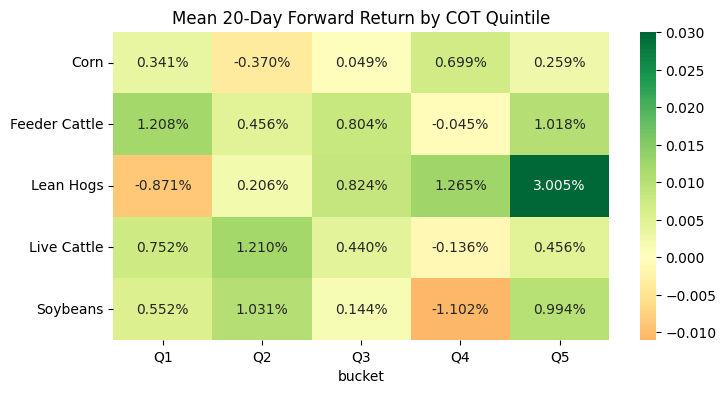

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

heat = bucket_results.pivot(index='market', columns='bucket', values='mean')

plt.figure(figsize=(8, 4))
sns.heatmap(heat, annot=True, fmt=".3%", cmap="RdYlGn", center=0)
plt.title("Mean 20-Day Forward Return by COT Quintile")
plt.ylabel("")
plt.show()


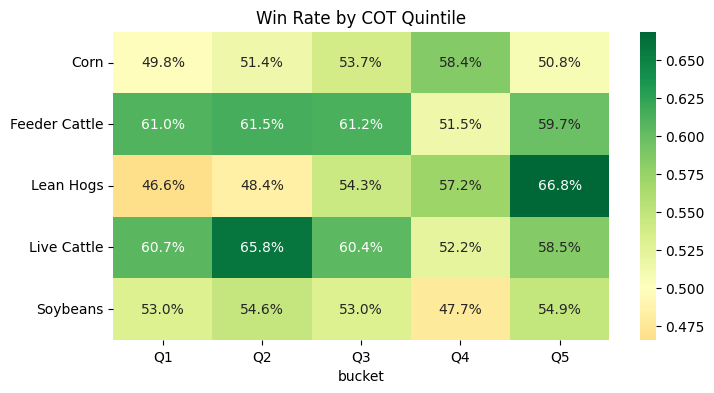

In [22]:
heat_wr = bucket_results.pivot(index='market', columns='bucket', values='win_rate')

plt.figure(figsize=(8, 4))
sns.heatmap(heat_wr, annot=True, fmt=".1%", cmap="RdYlGn", center=0.5)
plt.title("Win Rate by COT Quintile")
plt.ylabel("")
plt.show()



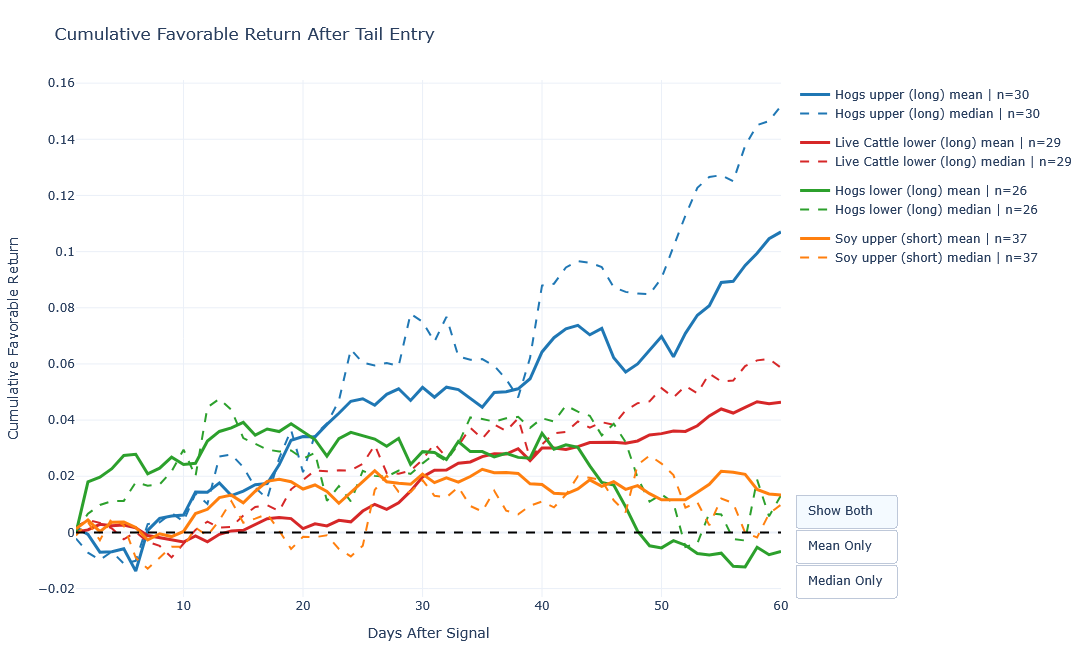

In [23]:
import numpy as np
import plotly.graph_objects as go

max_horizon = 60

signal_specs = [
    ("hogs", "Hogs upper", "upper", "long"),
    ("live_cattle", "Live Cattle lower", "lower", "long"),
    ("hogs", "Hogs lower", "lower", "long"),
    ("soy", "Soy upper", "upper", "short"),
]

series_data = []

for market, label, tail, direction in signal_specs:
    d = merged[market].loc["2008":].copy()
    close_col = next(c for c in d.columns if "Close" in c)
    d["ret"] = d[close_col].pct_change()

    if tail == "upper":
        d["tail_state"] = d["cot_idx"] >= 0.8
    else:
        d["tail_state"] = d["cot_idx"] <= 0.2

    prev_state = d["tail_state"].shift(1, fill_value=False)
    d["entry"] = d["tail_state"] & (~prev_state)

    entry_locs = np.where(d["entry"].values)[0]
    paths = []

    for loc in entry_locs:
        if loc + max_horizon >= len(d):
            continue

        future = d["ret"].iloc[loc + 1 : loc + 1 + max_horizon].values
        path = np.cumsum(future)

        if direction == "short":
            path = -path

        paths.append(path)

    if len(paths) == 0:
        continue

    paths = np.array(paths)

    series_data.append({
        "name": f"{label} ({direction})",
        "mean": paths.mean(axis=0),
        "median": np.median(paths, axis=0),
        "n": len(paths),
    })

fig = go.Figure()
x = np.arange(1, max_horizon + 1)

colors = [
    "#1f77b4",
    "#d62728",
    "#2ca02c",
    "#ff7f0e",
    "#9467bd",
    "#8c564b",
]

for i, s in enumerate(series_data):
    color = colors[i % len(colors)]
    group = s["name"]

    fig.add_trace(
        go.Scatter(
            x=x,
            y=s["mean"],
            mode="lines",
            name=f"{s['name']} mean | n={s['n']}",
            legendgroup=group,
            line=dict(color=color, width=3, dash="solid"),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Day %{x}<br>"
                "Return %{y:.2%}<extra></extra>"
            ),
            visible=True,
        )
    )

    fig.add_trace(
        go.Scatter(
            x=x,
            y=s["median"],
            mode="lines",
            name=f"{s['name']} median | n={s['n']}",
            legendgroup=group,
            line=dict(color=color, width=2, dash="dash"),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Day %{x}<br>"
                "Return %{y:.2%}<extra></extra>"
            ),
            visible=True,
        )
    )

n_signals = len(series_data)
both_visible = [True, True] * n_signals
mean_only = []
median_only = []

for _ in range(n_signals):
    mean_only.extend([True, False])
    median_only.extend([False, True])

fig.update_layout(
    title="Cumulative Favorable Return After Tail Entry",
    xaxis_title="Days After Signal",
    yaxis_title="Cumulative Favorable Return",
    hovermode="x unified",
    template="plotly_white",
    width=1250,
    height=650,
    margin=dict(l=70, r=260, t=80, b=70),
    updatemenus=[
        {
            "type": "buttons",
            "direction": "down",
            "x": 1.02,
            "y": 0.2,
            "xanchor": "left",
            "yanchor": "top",
            "showactive": True,
            "buttons": [
                {
                    "label": "Show Both",
                    "method": "update",
                    "args": [
                        {"visible": both_visible},
                        {"title": "Cumulative Favorable Return After Tail Entry"},
                    ],
                },
                {
                    "label": "Mean Only",
                    "method": "update",
                    "args": [
                        {"visible": mean_only},
                        {"title": "Mean Cumulative Favorable Return After Tail Entry"},
                    ],
                },
                {
                    "label": "Median Only",
                    "method": "update",
                    "args": [
                        {"visible": median_only},
                        {"title": "Median Cumulative Favorable Return After Tail Entry"},
                    ],
                },
            ],
        }
    ],
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1.0,
        xanchor="left",
        x=1.02
    ),
)

fig.add_hline(y=0, line_dash="dash", line_color="black")

fig.show()

In [24]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

signal_specs = [
    {
        "Signal": "Lean Hogs upper long",
        "market": "hogs",
        "tail": "upper",
        "direction": "long",
        "eval_horizon": 60,
    },
    {
        "Signal": "Lean Hogs lower long",
        "market": "hogs",
        "tail": "lower",
        "direction": "long",
        "eval_horizon": 20,  # exits before the decay kicks in
    },
    {
        "Signal": "Live Cattle lower long",
        "market": "live_cattle",
        "tail": "lower",
        "direction": "long",
        "eval_horizon": 60,
    },
    {
        "Signal": "Soy upper short",
        "market": "soy",
        "tail": "upper",
        "direction": "short",
        "eval_horizon": 30,
    },
]

drawdown_filters = [
    {"name": "No filter",               "col": "ret_20", "op": None,  "threshold": None},
    {"name": "Prior 20d <= -5%",        "col": "ret_20", "op": "<=",  "threshold": -0.05},
    {"name": "Prior 20d <= -10%",       "col": "ret_20", "op": "<=",  "threshold": -0.10},
]

entry_rules = [
    ("Day 0",  0),
    ("Day +1", 1),
    ("Day +3", 3),
    ("Day +5", 5),
]

def apply_filter(row, filt):
    if filt["op"] is None:
        return True
    value = row[filt["col"]]
    if pd.isna(value):
        return False
    if filt["op"] == "<=":
        return value <= filt["threshold"]
    if filt["op"] == ">=":
        return value >= filt["threshold"]
    raise ValueError(f"Unsupported operator: {filt['op']}")

def build_signal_frame(spec):
    d = merged[spec["market"]].loc["2008":].copy()
    close_col = next(c for c in d.columns if "Close" in c)

    d["ret_20"] = d[close_col].pct_change(20)

    if spec["tail"] == "upper":
        d["tail_state"] = (d["cot_idx"] >= 0.8).astype(bool)
    else:
        d["tail_state"] = (d["cot_idx"] <= 0.2).astype(bool)

    prev_state = d["tail_state"].shift(1, fill_value=False)
    d["entry_event"] = d["tail_state"] & (~prev_state)

    return d, close_col

def favorable_path_from_entry(d, close_col, loc, direction):
    entry_price = d[close_col].iloc[loc]
    window = d[close_col].iloc[loc : loc + spec["eval_horizon"] + 1]
    raw_path = window / entry_price - 1
    return raw_path if direction == "long" else -raw_path

all_results = []

for spec in signal_specs:
    d, close_col = build_signal_frame(spec)
    event_locs = np.where(d["entry_event"].values)[0]

    signal_rows = []

    for filt in drawdown_filters:
        eligible_locs = [
            loc for loc in event_locs
            if apply_filter(d.iloc[loc], filt)
        ]

        for entry_label, lag_days in entry_rules:
            trade_returns = []
            trade_mfe = []
            trade_peak_day = []

            for signal_loc in eligible_locs:
                entry_loc = signal_loc + lag_days
                exit_loc = entry_loc + spec["eval_horizon"]

                if entry_loc >= len(d) or exit_loc >= len(d):
                    continue

                fav_path = favorable_path_from_entry(d, close_col, entry_loc, spec["direction"])

                trade_returns.append(float(fav_path.iloc[-1]))
                trade_mfe.append(float(fav_path.max()))
                trade_peak_day.append(int(fav_path.values.argmax()))

            signal_rows.append({
                "Signal":          spec["Signal"],
                "Filter":          filt["name"],
                "Entry":           entry_label,
                "Lag Days":        lag_days,
                "n Trades":        len(trade_returns),
                "Mean Return":     np.mean(trade_returns)                        if trade_returns else np.nan,
                "Median Return":   np.median(trade_returns)                      if trade_returns else np.nan,
                "Win Rate":        np.mean(np.array(trade_returns) > 0)          if trade_returns else np.nan,
                "Avg MFE":         np.mean(trade_mfe)                            if trade_mfe     else np.nan,
                "Avg Peak Day":    np.mean(trade_peak_day)                       if trade_peak_day else np.nan,
            })

    signal_df = pd.DataFrame(signal_rows)
    all_results.append(signal_df)
    display(Markdown(f"### {spec['Signal']}"))
    display(signal_df)

master_df = pd.concat(all_results, ignore_index=True)
display(Markdown("## Master Comparison"))
display(master_df)

### Lean Hogs upper long

,Signal,Filter,Entry,Lag Days,n Trades,Mean Return,Median Return,Win Rate,Avg MFE,Avg Peak Day
0,Lean Hogs upper long,No filter,Day 0,0,30,0.109927,0.146589,0.733333,0.198482,41.200000
1,Lean Hogs upper long,No filter,Day +1,1,30,0.109349,0.148662,0.700000,0.198492,40.500000
2,Lean Hogs upper long,No filter,Day +3,3,30,0.126031,0.154251,0.700000,0.216725,42.733333
3,Lean Hogs upper long,No filter,Day +5,5,30,0.128539,0.148367,0.800000,0.224934,42.333333
4,Lean Hogs upper long,Prior 20d <= -5%,Day 0,0,9,0.084698,0.041965,0.666667,0.182228,44.555556
5,Lean Hogs upper long,Prior 20d <= -5%,Day +1,1,9,0.086211,0.056446,0.666667,0.184460,43.888889
6,Lean Hogs upper long,Prior 20d <= -5%,Day +3,3,9,0.103344,0.043406,0.666667,0.201291,43.333333
7,Lean Hogs upper long,Prior 20d <= -5%,Day +5,5,9,0.106813,0.052422,0.777778,0.208711,42.888889
8,Lean Hogs upper long,Prior 20d <= -10%,Day 0,0,7,0.070456,0.008763,0.571429,0.190840,41.000000
9,Lean Hogs upper long,Prior 20d <= -10%,Day +1,1,7,0.069226,0.013180,0.571429,0.190154,40.428571


### Lean Hogs lower long

,Signal,Filter,Entry,Lag Days,n Trades,Mean Return,Median Return,Win Rate,Avg MFE,Avg Peak Day
0,Lean Hogs lower long,No filter,Day 0,0,26,0.037154,0.024992,0.653846,0.086541,11.000000
1,Lean Hogs lower long,No filter,Day +1,1,26,0.034259,0.021938,0.576923,0.086923,10.153846
2,Lean Hogs lower long,No filter,Day +3,3,26,0.014663,-0.002265,0.500000,0.069375,10.076923
3,Lean Hogs lower long,No filter,Day +5,5,26,0.008710,-0.007743,0.461538,0.065869,9.423077
4,Lean Hogs lower long,Prior 20d <= -5%,Day 0,0,2,0.027575,0.027575,1.000000,0.065903,15.500000
5,Lean Hogs lower long,Prior 20d <= -5%,Day +1,1,2,0.013844,0.013844,0.500000,0.062981,14.500000
6,Lean Hogs lower long,Prior 20d <= -5%,Day +3,3,2,-0.013597,-0.013597,0.500000,0.045587,12.500000
7,Lean Hogs lower long,Prior 20d <= -5%,Day +5,5,2,-0.020802,-0.020802,0.000000,0.043851,10.500000
8,Lean Hogs lower long,Prior 20d <= -10%,Day 0,0,2,0.027575,0.027575,1.000000,0.065903,15.500000
9,Lean Hogs lower long,Prior 20d <= -10%,Day +1,1,2,0.013844,0.013844,0.500000,0.062981,14.500000


### Live Cattle lower long

,Signal,Filter,Entry,Lag Days,n Trades,Mean Return,Median Return,Win Rate,Avg MFE,Avg Peak Day
0,Live Cattle lower long,No filter,Day 0,0,29,0.046458,0.057504,0.724138,0.075977,42.275862
1,Live Cattle lower long,No filter,Day +1,1,29,0.046336,0.059977,0.724138,0.076212,43.896552
2,Live Cattle lower long,No filter,Day +3,3,29,0.048275,0.051298,0.793103,0.075372,44.827586
3,Live Cattle lower long,No filter,Day +5,5,29,0.045649,0.050465,0.862069,0.075835,43.586207
4,Live Cattle lower long,Prior 20d <= -5%,Day 0,0,0,NaN,NaN,NaN,NaN,NaN
5,Live Cattle lower long,Prior 20d <= -5%,Day +1,1,0,NaN,NaN,NaN,NaN,NaN
6,Live Cattle lower long,Prior 20d <= -5%,Day +3,3,0,NaN,NaN,NaN,NaN,NaN
7,Live Cattle lower long,Prior 20d <= -5%,Day +5,5,0,NaN,NaN,NaN,NaN,NaN
8,Live Cattle lower long,Prior 20d <= -10%,Day 0,0,0,NaN,NaN,NaN,NaN,NaN
9,Live Cattle lower long,Prior 20d <= -10%,Day +1,1,0,NaN,NaN,NaN,NaN,NaN


### Soy upper short

,Signal,Filter,Entry,Lag Days,n Trades,Mean Return,Median Return,Win Rate,Avg MFE,Avg Peak Day
0,Soy upper short,No filter,Day 0,0,37,0.020809,0.021424,0.621622,0.072349,17.594595
1,Soy upper short,No filter,Day +1,1,37,0.015667,0.019065,0.567568,0.071397,16.864865
2,Soy upper short,No filter,Day +3,3,37,0.016956,0.017065,0.594595,0.071163,16.972973
3,Soy upper short,No filter,Day +5,5,37,0.017300,0.000649,0.513514,0.067531,16.162162
4,Soy upper short,Prior 20d <= -5%,Day 0,0,9,0.074976,0.049840,0.888889,0.091513,22.333333
5,Soy upper short,Prior 20d <= -5%,Day +1,1,9,0.062896,0.032010,0.666667,0.089645,21.333333
6,Soy upper short,Prior 20d <= -5%,Day +3,3,9,0.069259,0.033880,0.888889,0.100584,22.666667
7,Soy upper short,Prior 20d <= -5%,Day +5,5,9,0.083319,0.047518,0.888889,0.104015,21.555556
8,Soy upper short,Prior 20d <= -10%,Day 0,0,4,0.082655,0.063382,1.000000,0.092161,22.500000
9,Soy upper short,Prior 20d <= -10%,Day +1,1,4,0.057834,0.036488,0.750000,0.083926,21.500000


## Master Comparison

,Signal,Filter,Entry,Lag Days,n Trades,Mean Return,Median Return,Win Rate,Avg MFE,Avg Peak Day
0,Lean Hogs upper long,No filter,Day 0,0,30,0.109927,0.146589,0.733333,0.198482,41.200000
1,Lean Hogs upper long,No filter,Day +1,1,30,0.109349,0.148662,0.700000,0.198492,40.500000
2,Lean Hogs upper long,No filter,Day +3,3,30,0.126031,0.154251,0.700000,0.216725,42.733333
3,Lean Hogs upper long,No filter,Day +5,5,30,0.128539,0.148367,0.800000,0.224934,42.333333
4,Lean Hogs upper long,Prior 20d <= -5%,Day 0,0,9,0.084698,0.041965,0.666667,0.182228,44.555556
5,Lean Hogs upper long,Prior 20d <= -5%,Day +1,1,9,0.086211,0.056446,0.666667,0.184460,43.888889
6,Lean Hogs upper long,Prior 20d <= -5%,Day +3,3,9,0.103344,0.043406,0.666667,0.201291,43.333333
7,Lean Hogs upper long,Prior 20d <= -5%,Day +5,5,9,0.106813,0.052422,0.777778,0.208711,42.888889
8,Lean Hogs upper long,Prior 20d <= -10%,Day 0,0,7,0.070456,0.008763,0.571429,0.190840,41.000000
9,Lean Hogs upper long,Prior 20d <= -10%,Day +1,1,7,0.069226,0.013180,0.571429,0.190154,40.428571


## Per-Trade Log

,Signal,Entry Date,Exit Date,Tranche,Raw Return,Kelly Frac,Sized Return,Win
0,Lean Hogs upper long,2008-01-25,2008-04-22,1,0.298487,0.326191,0.097364,True
1,Live Cattle lower long,2008-04-10,2008-07-07,1,0.156259,0.363985,0.056876,True
2,Lean Hogs lower long,2008-07-24,2008-08-21,1,-0.062088,0.201225,-0.012494,False
3,Soy upper short,2008-09-18,2008-10-30,1,0.223329,0.145319,0.032454,True
4,Lean Hogs lower long,2008-12-11,2009-01-12,1,0.094835,0.201225,0.019083,True
...,...,...,...,...,...,...,...,...
117,Live Cattle lower long,2025-06-20,2025-09-16,3,0.046744,0.363985,0.017014,True
118,Live Cattle lower long,2025-08-07,2025-10-31,3,-0.009005,0.363985,-0.003278,False
119,Lean Hogs lower long,2025-09-04,2025-10-02,1,0.038411,0.201225,0.007729,True
120,Live Cattle lower long,2025-10-30,2026-01-28,2,0.006588,0.363985,0.002398,True


## Summary Stats

,Signal,n Trades,Max Tranches,Win Rate,Mean Return,Kelly Fraction,Mean Sized Ret,Total Sized Ret,Avg Hold (days)
0,Lean Hogs upper long,30,3,0.800000,0.128539,0.326191,0.041928,1.257842,60.0
1,Live Cattle lower long,29,3,0.862069,0.045649,0.363985,0.016616,0.481855,60.0
2,Lean Hogs lower long,26,1,0.653846,0.037154,0.201225,0.007476,0.194386,20.0
3,Soy upper short,37,3,0.621622,0.020809,0.145319,0.003024,0.111884,30.0
4,ALL SIGNALS,122,3,0.729508,0.056688,NaN,0.016770,2.045967,NaN


**Portfolio Max Drawdown:** -7.79%

## Equity Curve

<Axes: title={'center': 'Compounded Wealth Index (Half-Kelly, max 3 tranches per asset)'}, xlabel='Date', ylabel='Wealth (starting at 1.0)'>

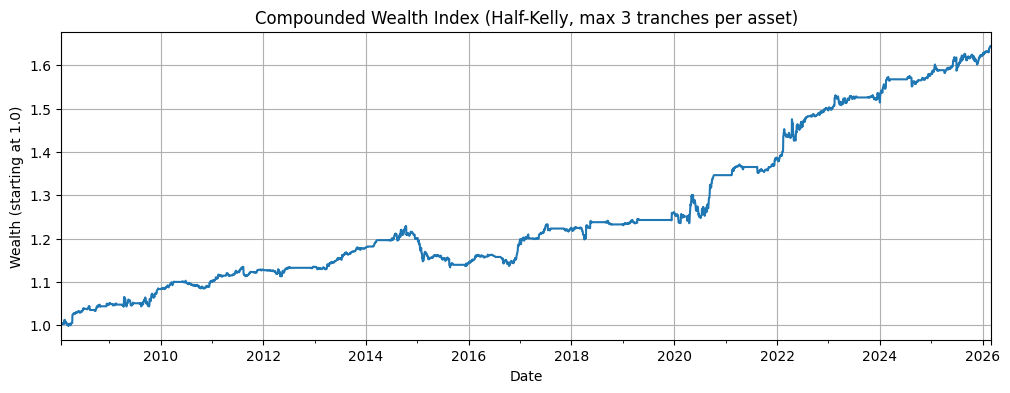

In [25]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# ── Signal configuration ────────────────────────────────────────────────────
signal_configs = [
    {
        "Signal":       "Lean Hogs upper long",
        "market":       "hogs",
        "tail":         "upper",
        "direction":    "long",
        "entry_lag":    5,
        "eval_horizon": 60,
    },
    {
        "Signal":       "Lean Hogs lower long",
        "market":       "hogs",
        "tail":         "lower",
        "direction":    "long",
        "entry_lag":    0,
        "eval_horizon": 20,
    },
    {
        "Signal":       "Live Cattle lower long",
        "market":       "live_cattle",
        "tail":         "lower",
        "direction":    "long",
        "entry_lag":    5,
        "eval_horizon": 60,
    },
    {
        "Signal":       "Soy upper short",
        "market":       "soy",
        "tail":         "upper",
        "direction":    "short",
        "entry_lag":    0,
        "eval_horizon": 30,
    },
]

MAX_TRANCHES = 3  # max simultaneous open tranches per asset

# ── Half-Kelly sizing ───────────────────────────────────────────────────────
def half_kelly(win_rate, avg_win, avg_loss):
    if avg_win <= 0 or avg_loss <= 0:
        return 0.0
    q = 1 - win_rate
    kelly = (win_rate * avg_win - q * avg_loss) / avg_win
    return float(np.clip(kelly / 2, 0, 1))

# ── Build signal frame ──────────────────────────────────────────────────────
def build_signal_frame(cfg):
    d = merged[cfg["market"]].loc["2008":].copy()
    close_col = next(c for c in d.columns if "Close" in c)
    d["ret_20"] = d[close_col].pct_change(20)

    if cfg["tail"] == "upper":
        d["tail_state"] = (d["cot_idx"] >= 0.8).astype(bool)
    else:
        d["tail_state"] = (d["cot_idx"] <= 0.2).astype(bool)

    prev_state = d["tail_state"].shift(1, fill_value=False)
    d["entry_event"] = d["tail_state"] & (~prev_state)
    return d, close_col

# ── Run backtest ────────────────────────────────────────────────────────────
all_trades = []
daily_pnl  = {}

for cfg in signal_configs:
    d, close_col = build_signal_frame(cfg)
    prices    = d[close_col]
    event_locs = np.where(d["entry_event"].values)[0]
    direction  = cfg["direction"]
    lag        = cfg["entry_lag"]
    horizon    = cfg["eval_horizon"]

    # ── Estimate Kelly from full trade history ──────────────────────────────
    raw_returns = []
    for sig_loc in event_locs:
        entry_loc = sig_loc + lag
        exit_loc  = entry_loc + horizon
        if exit_loc >= len(d):
            continue
        entry_price = prices.iloc[entry_loc]
        exit_price  = prices.iloc[exit_loc]
        ret = (exit_price / entry_price - 1) * (1 if direction == "long" else -1)
        raw_returns.append(ret)

    if len(raw_returns) == 0:
        continue

    raw_arr  = np.array(raw_returns)
    wins     = raw_arr[raw_arr > 0]
    losses   = raw_arr[raw_arr <= 0]
    win_rate = len(wins) / len(raw_arr)
    avg_win  = float(wins.mean())   if len(wins)   > 0 else 0.0
    avg_loss = float(-losses.mean()) if len(losses) > 0 else 0.0

    f = half_kelly(win_rate, avg_win, avg_loss)

    # ── Simulate trades with tranche cap ───────────────────────────────────
    # Track open tranches as list of exit locs
    open_tranches = []

    for sig_loc in event_locs:
        entry_loc = sig_loc + lag
        exit_loc  = entry_loc + horizon

        if entry_loc >= len(d) or exit_loc >= len(d):
            continue

        # Remove expired tranches
        open_tranches = [t for t in open_tranches if t > entry_loc]

        # Skip if at tranche cap
        if len(open_tranches) >= MAX_TRANCHES:
            continue

        open_tranches.append(exit_loc)

        entry_date  = d.index[entry_loc]
        exit_date   = d.index[exit_loc]
        entry_price = prices.iloc[entry_loc]
        exit_price  = prices.iloc[exit_loc]

        ret       = (exit_price / entry_price - 1) * (1 if direction == "long" else -1)
        sized_ret = f * ret

        # Daily MTM for equity curve
        for day_offset in range(1, horizon + 1):
            day_loc = entry_loc + day_offset
            if day_loc >= len(d):
                break
            day_date   = d.index[day_loc]
            prev_price = prices.iloc[day_loc - 1]
            curr_price = prices.iloc[day_loc]
            daily_ret  = (curr_price / prev_price - 1) * (1 if direction == "long" else -1)
            daily_pnl[day_date] = daily_pnl.get(day_date, 0.0) + (f * daily_ret) / len(signal_configs)

        all_trades.append({
            "Signal":       cfg["Signal"],
            "Entry Date":   entry_date,
            "Exit Date":    exit_date,
            "Entry Lag":    lag,
            "Horizon":      horizon,
            "Direction":    direction,
            "Entry Price":  entry_price,
            "Exit Price":   exit_price,
            "Raw Return":   ret,
            "Kelly Frac":   f,
            "Sized Return": sized_ret,
            "Win":          ret > 0,
            "Tranche":      len(open_tranches),
        })

# ── Trade log ───────────────────────────────────────────────────────────────
trade_df = pd.DataFrame(all_trades).sort_values("Entry Date").reset_index(drop=True)
trade_df["Entry Date"] = pd.to_datetime(trade_df["Entry Date"])
trade_df["Exit Date"]  = pd.to_datetime(trade_df["Exit Date"])

# ── Equity curve (compounded wealth) ────────────────────────────────────────
eq_series = pd.Series(daily_pnl).sort_index()
eq_series = eq_series.reindex(
    pd.bdate_range(eq_series.index.min(), eq_series.index.max()), fill_value=0.0
)
wealth = (1 + eq_series).cumprod()
wealth.name = "Wealth Index"

rolling_max = wealth.cummax()
max_dd = ((wealth - rolling_max) / rolling_max).min()

# ── Summary stats ────────────────────────────────────────────────────────────
def summarize(df):
    rows = []
    for sig in df["Signal"].unique():
        s = df[df["Signal"] == sig]
        rows.append({
            "Signal":          sig,
            "n Trades":        len(s),
            "Max Tranches":    s["Tranche"].max(),
            "Win Rate":        s["Win"].mean(),
            "Mean Return":     s["Raw Return"].mean(),
            "Kelly Fraction":  s["Kelly Frac"].iloc[0],
            "Mean Sized Ret":  s["Sized Return"].mean(),
            "Total Sized Ret": s["Sized Return"].sum(),
            "Avg Hold (days)": s["Horizon"].iloc[0],
        })
    summary = pd.DataFrame(rows)
    total_row = {
        "Signal":          "ALL SIGNALS",
        "n Trades":        len(df),
        "Max Tranches":    df["Tranche"].max(),
        "Win Rate":        df["Win"].mean(),
        "Mean Return":     df["Raw Return"].mean(),
        "Kelly Fraction":  np.nan,
        "Mean Sized Ret":  df["Sized Return"].mean(),
        "Total Sized Ret": df["Sized Return"].sum(),
        "Avg Hold (days)": np.nan,
    }
    return pd.concat([summary, pd.DataFrame([total_row])], ignore_index=True)

summary_df = summarize(trade_df)

# ── Display ──────────────────────────────────────────────────────────────────
display(Markdown("## Per-Trade Log"))
display(trade_df[[
    "Signal", "Entry Date", "Exit Date", "Tranche",
    "Raw Return", "Kelly Frac", "Sized Return", "Win"
]])

display(Markdown("## Summary Stats"))
display(summary_df)

display(Markdown(f"**Portfolio Max Drawdown:** {max_dd:.2%}"))

display(Markdown("## Equity Curve"))
wealth.plot(
    title="Compounded Wealth Index (Half-Kelly, max 3 tranches per asset)",
    figsize=(12, 4),
    ylabel="Wealth (starting at 1.0)",
    xlabel="Date",
    grid=True,
)

## Exposure Stacking Audit

,Metric,Value
0,Max Gross Exposure,1.418144
1,Max Net Exposure,1.418144
2,Max Concurrent Positions,3.000000


### Peak Leverage Dates

2014-09-05    1.418144
2014-09-08    1.418144
2014-09-09    1.418144
2014-09-10    1.418144
2014-09-11    1.418144
2014-09-12    1.418144
2014-09-15    1.418144
2014-09-16    1.418144
2014-09-17    1.418144
2014-09-18    1.418144
2014-09-19    1.418144
2014-09-22    1.418144
Freq: B, dtype: float64

## Asset-Level Exposure Summary

...

,Lean Hogs upper long,Live Cattle lower long,Lean Hogs lower long,Soy upper short
Lean Hogs upper long,1.000000,-0.178162,-0.150296,-0.062215
Live Cattle lower long,-0.178162,1.000000,-0.093447,-0.039735
Lean Hogs lower long,-0.150296,-0.093447,1.000000,-0.052710
Soy upper short,-0.062215,-0.039735,-0.052710,1.000000


## Regime Segmentation

,Regime,Annualized Mean Return
0,High Volatility,0.044674
1,Low Volatility,0.008105


## Capacity Stress Test

,Kelly Scale,CAGR,Max Drawdown,Calmar
0,0.25,0.006696,-0.019961,0.335452
1,0.50,0.013389,-0.039588,0.338221
2,1.00,0.026766,-0.077855,0.343796


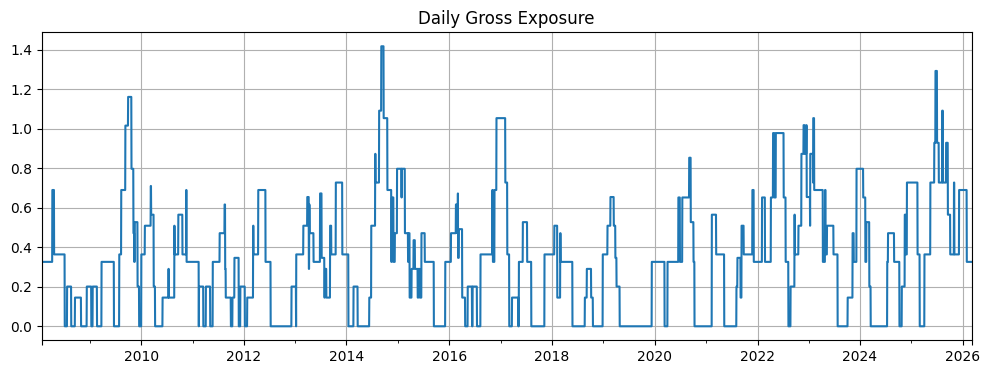

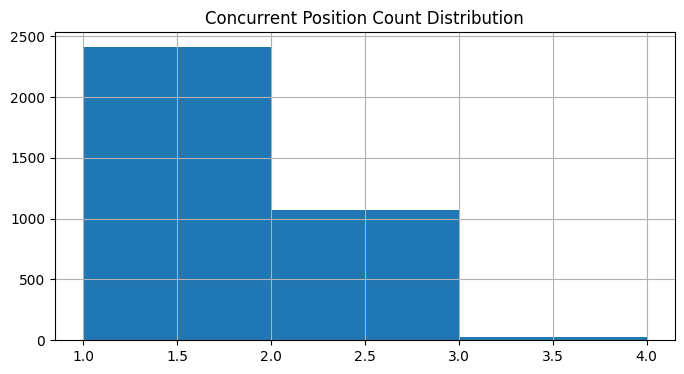

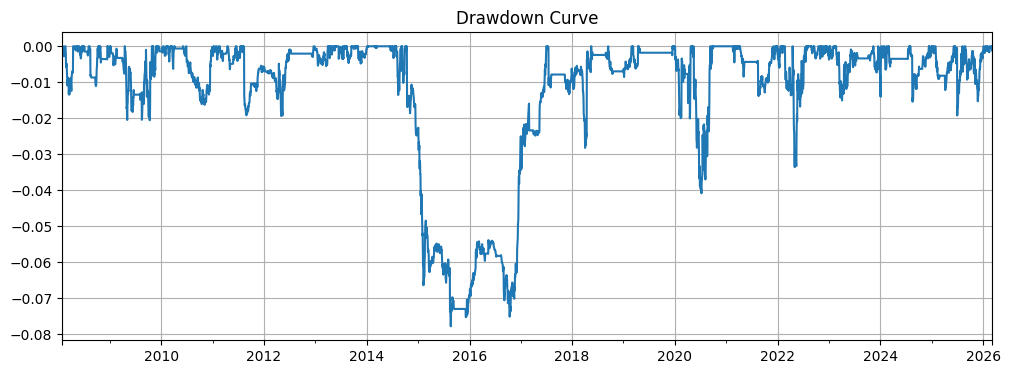

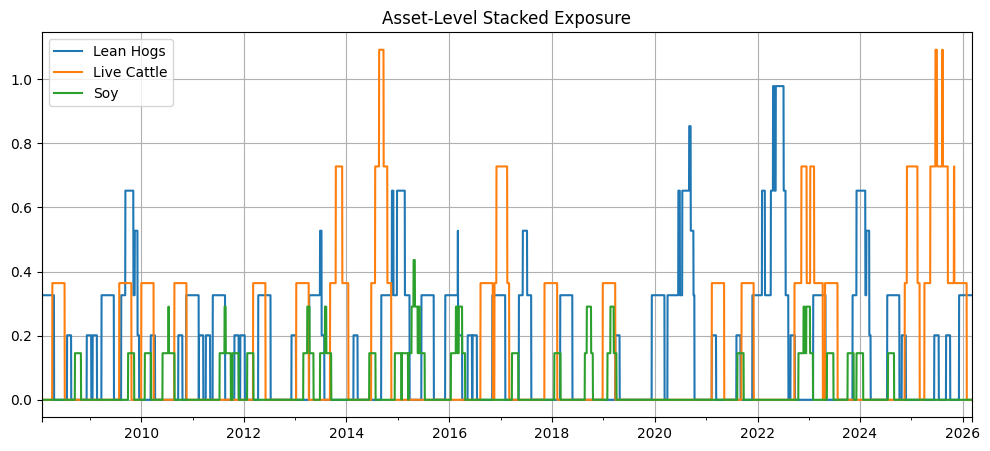

In [26]:
# ── Advanced portfolio diagnostics: exposure stacking + full risk audit ──
# Assumes these already exist from your backtest:
# trade_df, eq_series, wealth, summary_df, signal_configs

import numpy as np
import pandas as pd
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

# =========================================================
# 0.ASSET MAPPING (ADD THIS FIRST)
# =========================================================
signal_to_asset = {
    "Lean Hogs upper long": "Lean Hogs",
    "Lean Hogs lower long": "Lean Hogs",
    "Live Cattle lower long": "Live Cattle",
    "Soy upper short": "Soy"
}

trade_df["Asset"] = trade_df["Signal"].map(signal_to_asset)

# =========================================================
# 1. BUILD DAILY ACTIVE POSITION MATRIX
# =========================================================
calendar = pd.bdate_range(trade_df["Entry Date"].min(), trade_df["Exit Date"].max())

signal_names = trade_df["Signal"].unique()
active_matrix = pd.DataFrame(0.0, index=calendar, columns=signal_names)
signed_matrix = pd.DataFrame(0.0, index=calendar, columns=signal_names)

for _, row in trade_df.iterrows():
    days = pd.bdate_range(row["Entry Date"], row["Exit Date"])
    alloc = row["Kelly Frac"]
    sign = 1 if row["Direction"] == "long" else -1
    
    active_matrix.loc[days, row["Signal"]] += abs(alloc)
    signed_matrix.loc[days, row["Signal"]] += sign * alloc

# =========================================================
# 2.ASSET-LEVEL EXPOSURE MATRIX
# =========================================================
asset_names = trade_df["Asset"].unique()
asset_matrix = pd.DataFrame(0.0, index=calendar, columns=asset_names)

for _, row in trade_df.iterrows():
    days = pd.bdate_range(row["Entry Date"], row["Exit Date"])
    alloc = abs(row["Kelly Frac"])
    asset_matrix.loc[days, row["Asset"]] += alloc

asset_gross_exposure = asset_matrix.sum(axis=1)
asset_concentration = asset_matrix.div(
    asset_gross_exposure.replace(0, np.nan),
    axis=0
)

# =========================================================
# 3. EXPOSURE STACKING AUDIT
# =========================================================
gross_exposure = active_matrix.sum(axis=1)
net_exposure = signed_matrix.sum(axis=1)
concurrent_positions = (active_matrix > 0).sum(axis=1)

max_gross_exposure = gross_exposure.max()
max_net_exposure = net_exposure.abs().max()
max_concurrent_positions = concurrent_positions.max()

peak_leverage_dates = gross_exposure[gross_exposure == max_gross_exposure]

exposure_audit = pd.DataFrame({
    "Gross Exposure": gross_exposure,
    "Net Exposure": net_exposure,
    "Concurrent Positions": concurrent_positions
})

# =========================================================
# 4. SHARPE / SORTINO
# =========================================================
daily_returns = eq_series.copy()

ann_factor = np.sqrt(252)

sharpe = daily_returns.mean() / daily_returns.std() * ann_factor if daily_returns.std() > 0 else np.nan

downside = daily_returns[daily_returns < 0]
downside_std = downside.std()
sortino = daily_returns.mean() / downside_std * ann_factor if downside_std > 0 else np.nan

# =========================================================
# 5. PROFIT FACTOR
# =========================================================
gross_profit_raw = trade_df.loc[trade_df["Raw Return"] > 0, "Raw Return"].sum()
gross_loss_raw = -trade_df.loc[trade_df["Raw Return"] <= 0, "Raw Return"].sum()
profit_factor_raw = gross_profit_raw / gross_loss_raw if gross_loss_raw > 0 else np.nan

gross_profit_sized = trade_df.loc[trade_df["Sized Return"] > 0, "Sized Return"].sum()
gross_loss_sized = -trade_df.loc[trade_df["Sized Return"] <= 0, "Sized Return"].sum()
profit_factor_sized = gross_profit_sized / gross_loss_sized if gross_loss_sized > 0 else np.nan

# =========================================================
# 6. EXPECTANCY PER TRADE
# =========================================================
wins = trade_df[trade_df["Raw Return"] > 0]["Raw Return"]
losses = trade_df[trade_df["Raw Return"] <= 0]["Raw Return"]

win_rate = len(wins) / len(trade_df)
loss_rate = 1 - win_rate

avg_win = wins.mean() if len(wins) > 0 else 0
avg_loss = -losses.mean() if len(losses) > 0 else 0

expectancy = win_rate * avg_win - loss_rate * avg_loss

# =========================================================
# 7. MAX DRAWDOWN DURATION
# =========================================================
rolling_max = wealth.cummax()
drawdown = wealth / rolling_max - 1
underwater = drawdown < 0

dd_durations = []
current_dd = 0
for val in underwater:
    if val:
        current_dd += 1
    else:
        if current_dd > 0:
            dd_durations.append(current_dd)
        current_dd = 0
if current_dd > 0:
    dd_durations.append(current_dd)

max_dd_duration = max(dd_durations) if dd_durations else 0

# =========================================================
# 8. CAGR
# =========================================================
years = len(wealth) / 252
cagr = (wealth.iloc[-1] / wealth.iloc[0]) ** (1 / years) - 1

# =========================================================
# 9. CALMAR
# =========================================================
max_dd = drawdown.min()
calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

# =========================================================
# 10. SIGNAL OVERLAP CORRELATION MATRIX
# =========================================================
signal_overlap_corr = (active_matrix > 0).astype(int).corr()

# =========================================================
# 11. REGIME SEGMENTATION (volatility proxy)
# =========================================================
rolling_vol = daily_returns.rolling(20).std()
median_vol = rolling_vol.median()

high_vol_mask = rolling_vol > median_vol
low_vol_mask = rolling_vol <= median_vol

high_vol_ret = daily_returns[high_vol_mask].mean() * 252
low_vol_ret = daily_returns[low_vol_mask].mean() * 252

# =========================================================
# 12. TAIL RISK
# =========================================================
worst_day = daily_returns.min()
worst_5day = daily_returns.rolling(5).sum().min()

var_95 = np.percentile(daily_returns, 5)
cvar_95 = daily_returns[daily_returns <= var_95].mean()

# =========================================================
# 13. TIME UNDER WATER
# =========================================================
time_under_water = underwater.mean()

# =========================================================
# 14. CAPACITY STRESS TEST
# =========================================================
stress_levels = [0.25, 0.5, 1.0]
stress_results = []

for scale in stress_levels:
    scaled_daily = daily_returns * scale
    scaled_wealth = (1 + scaled_daily).cumprod()
    scaled_dd = scaled_wealth / scaled_wealth.cummax() - 1
    
    scaled_years = len(scaled_wealth) / 252
    scaled_cagr = (scaled_wealth.iloc[-1] / scaled_wealth.iloc[0]) ** (1 / scaled_years) - 1
    scaled_max_dd = scaled_dd.min()
    
    stress_results.append({
        "Kelly Scale": scale,
        "CAGR": scaled_cagr,
        "Max Drawdown": scaled_max_dd,
        "Calmar": scaled_cagr / abs(scaled_max_dd) if scaled_max_dd < 0 else np.nan
    })

stress_df = pd.DataFrame(stress_results)

# =========================================================
# DISPLAY METRICS
# =========================================================
display(Markdown("## Exposure Stacking Audit"))
display(pd.DataFrame({
    "Metric": [
        "Max Gross Exposure",
        "Max Net Exposure",
        "Max Concurrent Positions"
    ],
    "Value": [
        max_gross_exposure,
        max_net_exposure,
        max_concurrent_positions
    ]
}))

display(Markdown("### Peak Leverage Dates"))
display(peak_leverage_dates)

display(Markdown("## Asset-Level Exposure Summary"))
display(asset_matrix.describe().T)

display(Markdown("## Risk Metrics"))
risk_metrics = pd.DataFrame({
    "Metric": [
        "Sharpe Ratio",
        "Sortino Ratio",
        "Profit Factor (Raw)",
        "Profit Factor (Sized)",
        "Expectancy per Trade",
        "CAGR",
        "Max Drawdown",
        "Max DD Duration (days)",
        "Calmar Ratio",
        "Worst Day",
        "Worst 5-Day Loss",
        "VaR 95%",
        "CVaR 95%",
        "Time Under Water"
    ],
    "Value": [
        sharpe,
        sortino,
        profit_factor_raw,
        profit_factor_sized,
        expectancy,
        cagr,
        max_dd,
        max_dd_duration,
        calmar,
        worst_day,
        worst_5day,
        var_95,
        cvar_95,
        time_under_water
    ]
})
display(risk_metrics)

display(Markdown("## Signal Overlap Correlation Matrix"))
display(signal_overlap_corr)

display(Markdown("## Regime Segmentation"))
display(pd.DataFrame({
    "Regime": ["High Volatility", "Low Volatility"],
    "Annualized Mean Return": [high_vol_ret, low_vol_ret]
}))

display(Markdown("## Capacity Stress Test"))
display(stress_df)

# =========================================================
# PLOTS
# =========================================================

# Gross exposure over time
gross_exposure.plot(figsize=(12,4), title="Daily Gross Exposure")
plt.grid(True)
plt.show()

# Concurrent positions histogram
concurrent_positions.hist(figsize=(8,4), bins=range(1, max_concurrent_positions+2))
plt.title("Concurrent Position Count Distribution")
plt.grid(True)
plt.show()

# Drawdown curve
drawdown.plot(figsize=(12,4), title="Drawdown Curve")
plt.grid(True)
plt.show()

asset_matrix.plot(figsize=(12,5), title="Asset-Level Stacked Exposure")
plt.grid(True)
plt.show()